#simple Chain model

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()

model = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=""
)

prompt = PromptTemplate(
    template="Generate 5 interesting facts about {topic}",
    input_variables=["topic"]
)

parser = StrOutputParser()

chain = prompt | model | parser

result = chain.invoke({"topic": "science"})
print(result)

Here are five interesting facts about science:

1. **Butterflies Taste with Their Feet**: Butterflies have taste receptors on their feet, which help them detect the sweetness or bitterness of a substance. This helps them choose the right plants to feed on and lay their eggs. The taste receptors are located on the tiny sensory hairs on their feet, and they can even detect the difference between sweet and bitter substances.

2. **There is a Type of Jellyfish that is Immortal**: The Turritopsis dohrnii, also known as the "immortal jellyfish," is a type of jellyfish that can transform its body into a younger state through a process called transdifferentiation. This means that it can essentially revert back to its polyp stage, which is the juvenile form of a jellyfish, and then grow back into an adult again. This process can be repeated indefinitely, making the Turritopsis dohrnii theoretically immortal.

3. **The Human Nose Can Detect Over 1 Trillion Scents**: The human sense of smell is i

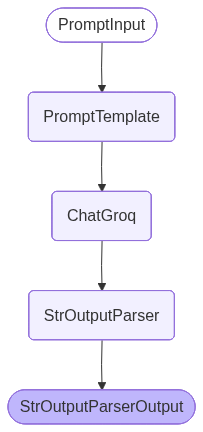

In [ ]:
from IPython.display import Image, display

display(Image(chain.get_graph().draw_mermaid_png()))

#sequential chain

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

prompt1 = PromptTemplate(
    template="Generate me a short report on {topic}",
    input_variables=["topic"]
)

prompt2 = PromptTemplate(
    template="Give me 2 important points from the following text:\n{text}",
    input_variables=["text"]
)

model = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=""
)

parser = StrOutputParser()

chain = prompt1 | model | parser | prompt2 | model | parser

result = chain.invoke(
    {"topic": "How Gen Z differs from other generations"}
)

print(result)

Here are 2 important points from the text:

1. **Gen Z is digitally native**: They are the first generation to grow up with the internet and social media, making them highly tech-savvy and accustomed to instant access to information.
2. **Gen Z values diversity, inclusivity, and pragmatism**: They are the most ethnically and culturally diverse generation, with a strong emphasis on inclusivity, social justice, and environmental awareness, and are also more practical and entrepreneurial, focusing on financial stability and career advancement.


#parallel chain
*   first we will biuld teh notes from given topic
*   second we will genrate quiz from the gven topic
*   we will show both thing to user


In [3]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq
from langchain_core.runnables import RunnableParallel
from dotenv import load_dotenv

load_dotenv()

# Model
model = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=""
)

# Prompts
prompt1 = PromptTemplate(
    template="Genrate easy and simple notes from the following text:\n{text}",
    input_variables=["text"]
)

prompt2 = PromptTemplate(
    template="Generate 5 short answer questions from the following text:\n{text}",
    input_variables=["text"]
)

prompt3 = PromptTemplate(
    template="""
Merge the following notes and quiz into a single document.

Notes:
{notes}

Quiz:
{quiz}
""",
    input_variables=["notes", "quiz"]
)

# Parser
parser = StrOutputParser()

# Parallel Chain
parallel_chain = RunnableParallel(
    {
        "notes": prompt1 | model | parser,
        "quiz": prompt2 | model | parser,
    }
)

# Merger Chain
merger_chain = prompt3 | model | parser

# Final Chain
chain = parallel_chain | merger_chain

# Input Text
text = """
How it works

Imagine you have data points plotted on a graph. Linear regression finds the line that minimizes the difference between:

the actual data points, and
the predicted values from the line

This difference is usually measured using something called mean squared error (MSE).

Types of linear regression
Simple linear regression
One input variable
Example: Predicting salary based on years of experience
Multiple linear regression
Multiple input variables
Example: Predicting house price using size, location, and number of bedrooms

The formula expands to:

y=b+m1x1+m2x2+m3x3...
Why it’s useful

Linear regression is popular because it’s:

Easy to understand and interpret
Fast to compute
A strong baseline model in many problems

It’s used in areas like:

Economics (forecasting trends)
Business (sales prediction)
Science (understanding relationships between variables)
Limitations

Despite its simplicity, it has some constraints:

Assumes a linear relationship (not always true)
Sensitive to outliers
Can struggle with complex, non-linear data
"""

# Run
result = chain.invoke({"text": text})

print(result)

**Linear Regression: Notes and Quiz**

### Introduction to Linear Regression

Linear regression is a statistical method that finds the line that minimizes the difference between actual data points and predicted values. The difference is measured using Mean Squared Error (MSE), which calculates the average of the squared differences between actual and predicted values.

### Types of Linear Regression

There are two main types of linear regression:

1. **Simple Linear Regression**: This type of linear regression involves one input variable. For example, predicting salary based on years of experience. Simple linear regression is useful when there is a single factor that affects the outcome.
2. **Multiple Linear Regression**: This type of linear regression involves multiple input variables. For example, predicting house price using size, location, and bedrooms. Multiple linear regression is useful when there are several factors that affect the outcome.

### Why is Linear Regression Useful?

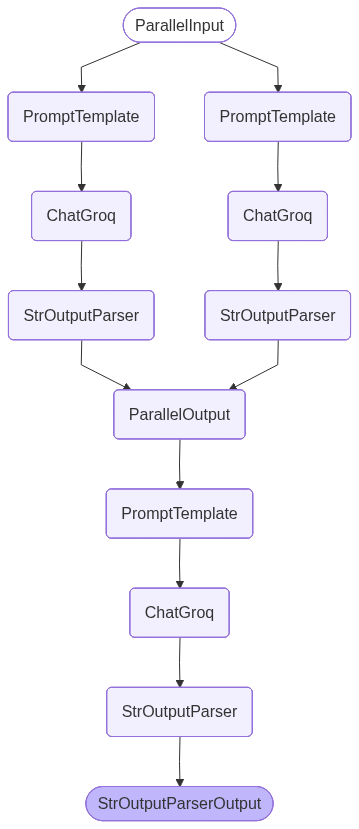

In [4]:
from IPython.display import Image, display

display(Image(chain.get_graph().draw_mermaid_png()))

#conditional Chain

```
               feed back
                  |
               analyze
                  |
   --------------------------------               
   |                              |     
positive                        negavative
feedback                        feedbach
plz rate us 5 rate              we will improve
```

In [6]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnableParallel, RunnableBranch, RunnableLambda
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from typing import Literal

load_dotenv()

model = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=""
)

parser = StrOutputParser()

class Feedback(BaseModel):

    sentiment: Literal['positive', 'negative'] = Field(description='Give the sentiment of the feedback')

parser2 = PydanticOutputParser(pydantic_object=Feedback)

prompt1 = PromptTemplate(
    template='Classify the sentiment of the following feedback text into postive or negative \n {feedback} \n {format_instruction}',
    input_variables=['feedback'],
    partial_variables={'format_instruction':parser2.get_format_instructions()}
)

classifier_chain = prompt1 | model | parser2

prompt2 = PromptTemplate(
    template='Write an appropriate response to this positive feedback \n {feedback}',
    input_variables=['feedback']
)

prompt3 = PromptTemplate(
    template='Write an appropriate response to this negative feedback \n {feedback}',
    input_variables=['feedback']
)

branch_chain = RunnableBranch(
    (lambda x:x.sentiment == 'positive', prompt2 | model | parser),
    (lambda x:x.sentiment == 'negative', prompt3 | model | parser),
    RunnableLambda(lambda x: "could not find sentiment")
)
'''
branch_chain = RunnableBranch(
    (condition, chain),
    (condition, chain),
    default value
)

it is like
if
if else
else
#there should alway be the defalut value

for default we can not write it like this
lambda x :"could not find sentiment" ---> this is not a chain
it will give error
beacuse there is no chaine so we have to convert the x lambda into runnable parameter

for that we have to
import RunnableLambda
from langchain.schema.runnable import RunnableLambda

RunnableLambda(lambda x: "could not find sentiment")

'''

chain = classifier_chain | branch_chain

print(chain.invoke({'feedback': 'This is a beautiful phone'}))






Thank you so much for your kind words. We're thrilled to hear that you're happy with our service/product. Your feedback is truly appreciated and we're glad we could meet your expectations. If you have any other questions or need further assistance, please don't hesitate to reach out. We're always here to help and look forward to serving you again in the future.


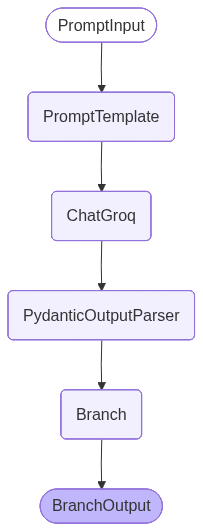

In [7]:
display(Image(chain.get_graph().draw_mermaid_png()))